In [1]:
rm -rf /kaggle/working/*

# Imports

In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import zipfile
import os
import random
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import random
import cv2
import shutil
import tensorflow as tf
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

2025-07-04 12:50:47.635032: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1751633447.879672      13 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1751633447.950678      13 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


/kaggle/input/dogs-vs-cats/test1.zip
/kaggle/input/dogs-vs-cats/train.zip
/kaggle/input/dogs-vs-cats/sampleSubmission.csv


# Problem Statement and Data

Figure out if an image is a cat or dog, 1 = Dog and 0 = cat. The training archive contains 25,000 images of dogs and cats. Apparently machine classifiers can score above 80% accuracy on this task. My goal as a novice is to get as close to 80% as I can. 



# Importing Data

In [3]:
# Extract the zip file
def extract_zip(zip_path, extract_to):
    abs_path = os.path.abspath(extract_to)

    if not os.path.exists(abs_path):
        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            zip_ref.extractall(extract_to)
        print("Extracted to: ", extract_to)
    else:
        print("Data already loaded for: ", zip_path)

    zip_dir = os.path.basename(zip_path)
    zip_name = os.path.splitext(zip_dir)[0]
    jpg_path = os.path.join(abs_path, zip_name)

    return jpg_path

# Extract your data

train_path = extract_zip('/kaggle/input/dogs-vs-cats/train.zip', './train_ext')
test_path = extract_zip('/kaggle/input/dogs-vs-cats/test1.zip', './test_ext')

Extracted to:  ./train_ext
Extracted to:  ./test_ext


# Data Exploration

## Move Files to class-labeled folders

In [4]:
def move_file_class(parent_dir, class_list, new_dir_name):
    src_class_path = [os.path.join(parent_dir, x) for x in class_list]
    target_class_path = os.path.join(parent_dir, new_dir_name) 
    print(target_class_path)
    #print(src_class_path[0])
    
    if not os.path.exists(target_class_path):
        Path(target_class_path).mkdir(parents=True, exist_ok=True)
        [shutil.move(x, target_class_path) for x in src_class_path]
    else:
        print("Already created the file paths")

    return target_class_path


train_files = [ f for f in os.listdir(train_path) if os.path.isfile(os.path.join(train_path, f))]
cat_files = [x for x in train_files if 'cat' in x]
dog_files = [x for x in train_files if 'dog' in x]
class_len = len(cat_files) + len(dog_files)

train_cat_path = move_file_class(train_path, cat_files, 'cat')
train_dog_path = move_file_class(train_path, dog_files, 'dog')
print("total images: ", class_len)

/kaggle/working/train_ext/train/cat
/kaggle/working/train_ext/train/dog
total images:  25000


## Look at a few images

/kaggle/working/train_ext/train/cat/cat.3811.jpg


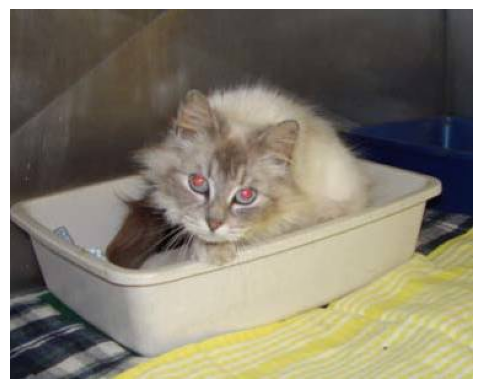

/kaggle/working/train_ext/train/dog/dog.4449.jpg


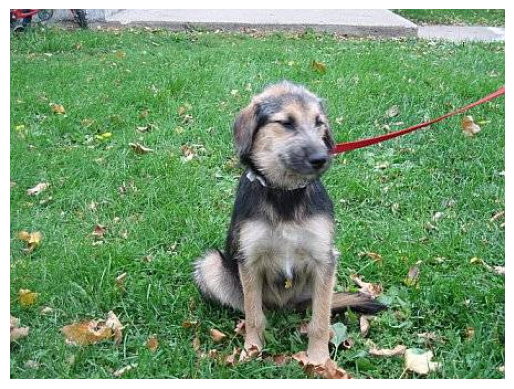

/kaggle/working/train_ext/train/cat/cat.9817.jpg


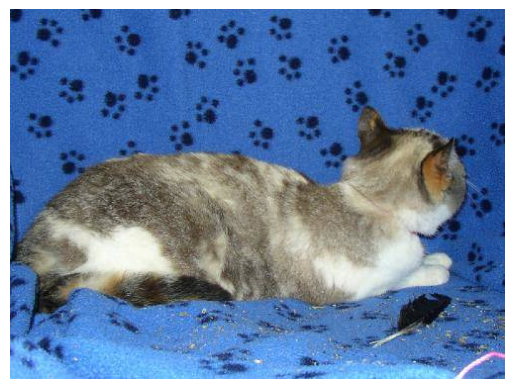

/kaggle/working/train_ext/train/dog/dog.12173.jpg


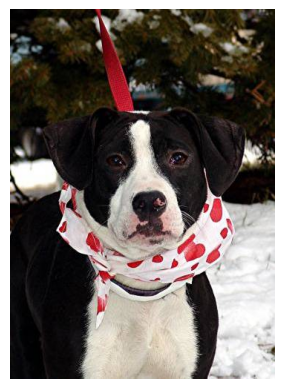

/kaggle/working/train_ext/train/cat/cat.4741.jpg


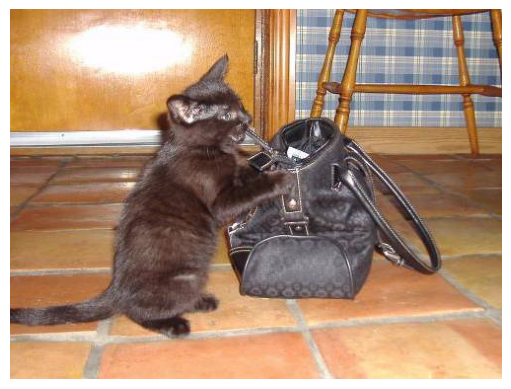

/kaggle/working/train_ext/train/cat/cat.5153.jpg


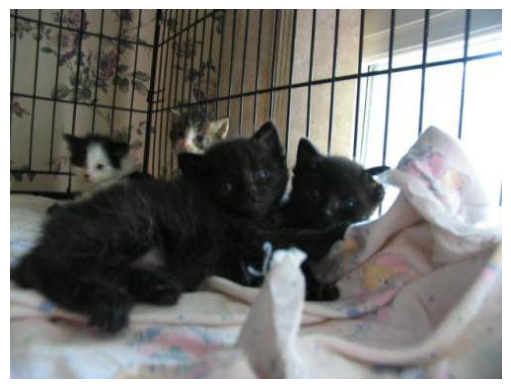

/kaggle/working/train_ext/train/cat/cat.3148.jpg


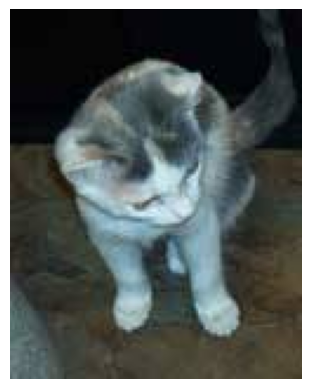

/kaggle/working/train_ext/train/dog/dog.299.jpg


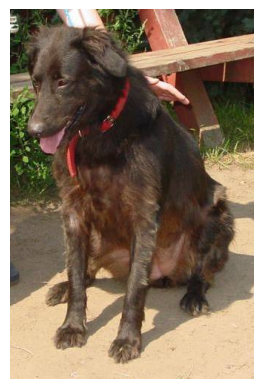

/kaggle/working/train_ext/train/dog/dog.5193.jpg


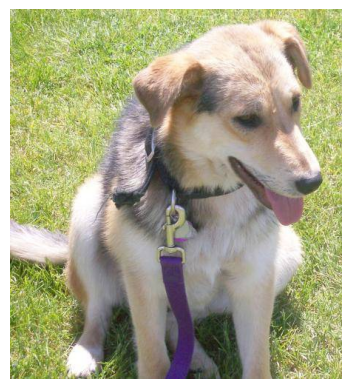

/kaggle/working/train_ext/train/cat/cat.4270.jpg


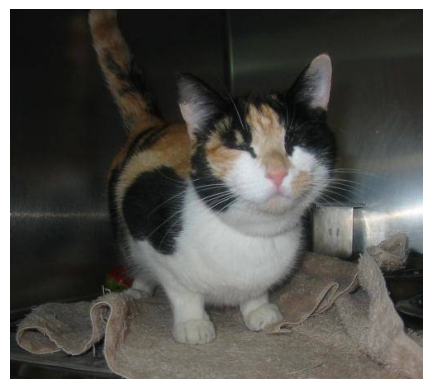

In [5]:
# Randomly select a image to show
cat_files = [os.path.join(train_cat_path,f) for f in os.listdir(train_cat_path) if os.path.isfile(os.path.join(train_cat_path, f))]
dog_files = [os.path.join(train_dog_path,f) for f in os.listdir(train_dog_path) if os.path.isfile(os.path.join(train_dog_path, f))]
files = cat_files + dog_files  

for i in range(10):
    jpg_file = random.choice(files)
    print(jpg_file)    
    
    # Plot Image
    img = mpimg.imread(jpg_file)
    plt.imshow(img)
    plt.axis('off')  # Hide axes
    plt.show()

2 classes: Cats and Dogs


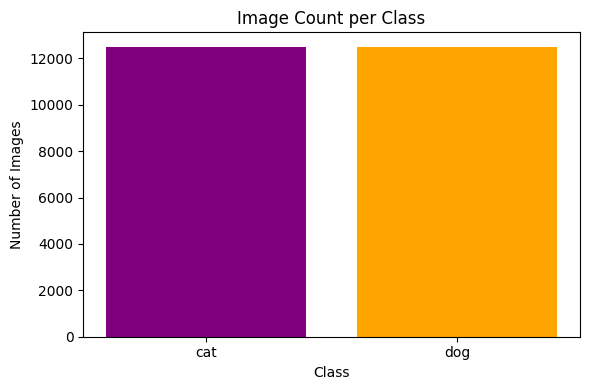

In [6]:
if class_len != len(train_files):
    print("missing classes")
else:
    print("2 classes: Cats and Dogs")
      
# Count
counts = {'cat': len(cat_files), 'dog': len(dog_files)}

# Plot
plt.figure(figsize=(6, 4))
plt.bar(counts.keys(), counts.values(), color=['purple', 'orange'])
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.title("Image Count per Class")
plt.tight_layout()
plt.show()

## Image Information

In [7]:
data = []
for jpg in files:
    try:
        img = cv2.imread(jpg)
        height, width, channels = img.shape
        data.append({
                "filename": jpg,
                "height": height,
                "width": width,
                "channels": channels
            })
    except Exception as e:
        print(f"Error reading {jpg}: {e}")

df = pd.DataFrame(data)
print("Head:\n", df.head())
print("\n")
print("Shape:\n ", df.shape)
print("\n")
print("Info:\n")
df.info()
print("\n")
print("Describe:\n", df.describe())

Head:
                                             filename  height  width  channels
0   /kaggle/working/train_ext/train/cat/cat.8260.jpg     374    500         3
1  /kaggle/working/train_ext/train/cat/cat.10373.jpg     499    375         3
2   /kaggle/working/train_ext/train/cat/cat.8015.jpg     454    499         3
3  /kaggle/working/train_ext/train/cat/cat.10572.jpg     374    500         3
4    /kaggle/working/train_ext/train/cat/cat.391.jpg     200    179         3


Shape:
  (25000, 4)


Info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   filename  25000 non-null  object
 1   height    25000 non-null  int64 
 2   width     25000 non-null  int64 
 3   channels  25000 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 781.4+ KB


Describe:
              height        width  channels
count  25000.000000  25000.00000   25000.0
mean   

## Plot Image Info

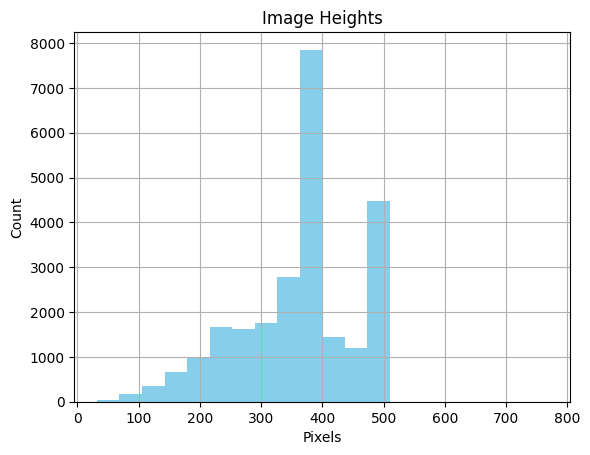

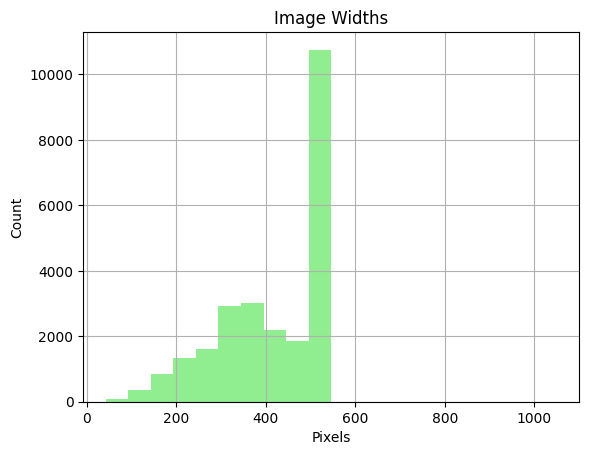

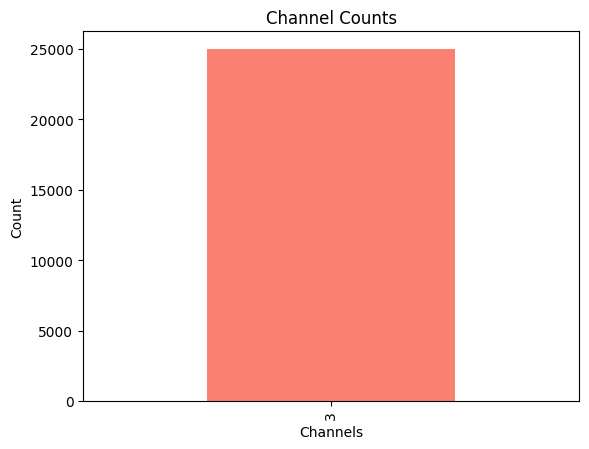

In [8]:
# Plots
bins = 20

df['height'].hist(bins=bins, color='skyblue')
plt.title("Image Heights")
plt.xlabel("Pixels")
plt.ylabel("Count")
plt.show()

df['width'].hist(bins=bins, color='lightgreen')
plt.title("Image Widths")
plt.xlabel("Pixels")
plt.ylabel("Count")
plt.show()

df['channels'].value_counts().plot(kind='bar', color='salmon')
plt.title("Channel Counts")
plt.xlabel("Channels")
plt.ylabel("Count")
plt.show()

# Prepare Data Set

## Load Data and create pipeline

In [9]:
# Load training and create validation sets
batch_size = 32
img_height = 180
img_width = 180
train_dir = '/kaggle/working/train_ext/train'

_ds_train = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

# Data Pipeline
def convert_to_float(image, label):
    image = tf.image.convert_image_dtype(image, dtype=tf.float32)
    return image, label

AUTOTUNE = tf.data.experimental.AUTOTUNE

_ds_val = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

ds_train = (
    _ds_train
    .map(convert_to_float)
    .cache()
    .prefetch(buffer_size=AUTOTUNE)
)

ds_valid = (
    _ds_val
    .map(convert_to_float)
    .cache()
    .prefetch(buffer_size=AUTOTUNE)
)

Found 25000 files belonging to 2 classes.
Using 20000 files for training.


2025-07-04 12:51:43.481212: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Found 25000 files belonging to 2 classes.
Using 5000 files for validation.


# Training Model

## Use pre-trained base 

In [10]:
pretrained_base = EfficientNetB0(
    include_top=False,               
    weights='imagenet',             
    input_shape=(img_height, img_width, 3)
)

pretrained_base.trainable = False

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
